In [7]:
import numpy as np

In [ ]:
from graphviz import Digraph

def trace(root):
    """ 构建梯度计算图 """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label=f'{n.label} | data {n.data:.4f} | grad {n.grad:.4f}', shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [9]:
class Value:
    """ 仅限整数类型 """
    def __init__(self, data, label='', _children=(), _op='') -> None:
        self.data = data
        self.label = label
        self._prev = set(_children)
        self._op = _op

        self.grad = 0.
        self._backward = lambda: None
        self._backward_name = ''

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        
        def _backward():
            self.grad += 1. * out.grad
            other.grad += 1. * out.grad

        out._backward = _backward
        out._backward_name = 'add'
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        out._backward_name = 'mul'
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only supporting int/float powers for now'
        out = Value(self.data ** other, _children=(self,), _op=f'**{other}')

        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        
        out._backward = _backward
        out._backward_name = 'pow'
        return out
    
    def tanh(self):
        x = self.data
        t = (np.exp(2 * x) - 1) / (np.exp(2 * x) + 1)
        out = Value(t, _children=(self,), _op='tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        
        out._backward = _backward
        out._backward_name = 'tanh'
        return out
    
    def backward(self):
        topo = []
        vis = set()

        def build(node):
            if node not in vis:
                vis.add(node)
                for o in node._prev:
                    build(o)
                topo.append(node)
        
        build(self)
        
        self.grad = 1.
        for node in reversed(topo):
            node._backward()

    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self) 

    def __truediv__(self, other):
        return self * other ** -1
    
    def __rtruediv__(self, other):
        return other * self ** -1

    def __repr__(self):
        return f'Value(label={self.label}, data={self.data}, grad={self.grad}, grad_fn={self._backward_name})'

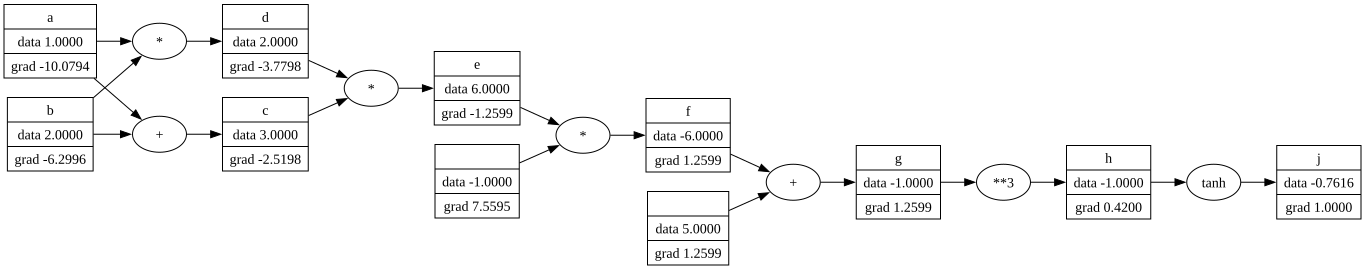

In [10]:
# 绘制梯度传播图
a = Value(1, 'a')
b = Value(2, 'b')
c = a + b;      c.label = 'c'
d = a * b;      d.label = 'd'
e = c * d;      e.label = 'e'
f = -e;         f.label = 'f'
g = 5 + f;      g.label = 'g'
h = g ** 3;     h.label = 'h'
j = h.tanh();   j.label = 'j'
j.backward()
draw_dot(j)

In [11]:
# 验证梯度传播的正确性
import torch

at = torch.Tensor([1.]).double();   at.requires_grad = True
bt = torch.Tensor([2.]).double();   bt.requires_grad = True
ct = at + bt;                       ct.retain_grad()
dt = at * bt;                       dt.retain_grad()
et = ct * dt;                       et.retain_grad()
ft = -et;                           ft.retain_grad()
gt = 5 + ft;                        gt.retain_grad()
ht = gt ** 3;                       ht.retain_grad()
jt = torch.tanh(ht);                jt.retain_grad()

jt.backward()
print(jt.data.item())
print('*' * 20)
for tt, t in zip([at, bt, ct, dt, et, ft, gt, ht, jt], [a, b, c, d, e, f, g, h, j]):
    print(tt.grad.item() == t.grad)

-0.7615941559557649
********************
True
True
True
True
True
True
True
True
True


# MLP

In [12]:
import random

class Neuron:
    def __init__(self, nin) -> None:
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        out = sum((_w * _x for _w, _x in zip(self.w, x)), self.b)
        out = out.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    

class Layer:
    def __init__(self, nin, nout) -> None:
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        out = [neuron(x) for neuron in self.neurons]
        return out
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    

class MLP:
    def __init__(self, nin, nout) -> None:
        nout.insert(0, nin)
        self.layers = [Layer(nout[i], nout[i + 1]) for i in range(len(nout) - 1)]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

def zero_grad(parameters):
    for p in parameters:
        p.grad = 0.

def update(parameters, lr=0.1):
    for p in parameters:
        p.data -= lr * p.grad

In [13]:
# 利用一些数据反演 targets 中的参数
inputs = [
    [2., 3., -1.],
    [3., -1., 0.5],
    [0.5, 1., 1.],
    [1., 1., -1.]
]
targets = [1., 1., -1., -1.]
mlp = MLP(3, [4, 4, 1])

In [14]:
# 训练一个 mlp 并拟合参数
epochs = 100

for epoch in range(epochs):
    zero_grad(mlp.parameters())

    pred = [mlp(x)[0] for x in inputs]
    loss = sum((p - t) ** 2 for p, t in zip(pred, targets))

    loss.backward()
    update(mlp.parameters())

    if epoch % 5 == 0:
        print(f'Epoch {epoch}, loss = {loss.data:.4f}')

print([x.data for x in pred], targets)

Epoch 0, loss = 5.2320
Epoch 5, loss = 2.4473
Epoch 10, loss = 2.3546
Epoch 15, loss = 2.3085
Epoch 20, loss = 2.0649
Epoch 25, loss = 2.3047
Epoch 30, loss = 1.6420
Epoch 35, loss = 2.0542
Epoch 40, loss = 0.8100
Epoch 45, loss = 0.0573
Epoch 50, loss = 0.0380
Epoch 55, loss = 0.0284
Epoch 60, loss = 0.0226
Epoch 65, loss = 0.0187
Epoch 70, loss = 0.0159
Epoch 75, loss = 0.0138
Epoch 80, loss = 0.0121
Epoch 85, loss = 0.0108
Epoch 90, loss = 0.0098
Epoch 95, loss = 0.0089
[np.float64(0.9371466511904135), np.float64(0.9820505974584519), np.float64(-0.9463045555584282), np.float64(-0.9668431412715114)] [1.0, 1.0, -1.0, -1.0]
